# 02. Sanitización y Construcción de Métricas

## Qué quiero lograr

En este cuaderno quiero transformar el entendimiento del raw en una capa procesada estable. Mi criterio aquí es simple: no basta con limpiar; necesito dejar artefactos que después sirvan al backend, al dashboard y al bot sin volver a reinterpretar el raw cada vez.

## Cómo lo voy a validar

Voy a verificar:

1. que el pipeline produce salidas trazables,
2. que la serie canónica cumple un contrato técnico fuerte,
3. que los agregados diarios y horarios son útiles para producto,
4. que las anomalías salgan con contexto suficiente para no sobreactuar.


## Preparación del entorno

Antes de correr el pipeline, dejo el notebook alineado con el código reutilizable del repo. También importo utilidades para expresar mejor confianza, cobertura y catálogo de artefactos.

Quiero que el notebook sea un lugar para validar la implementación productiva, no para crear una lógica paralela difícil de mantener.


In [11]:
from __future__ import annotations

import os
import sys
from dataclasses import asdict
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "data" / "raw").exists():
    ROOT = ROOT.parent

os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".matplotlib"))
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from scripts.process_availability_data import STANDARD_CADENCE_SECONDS, run_pipeline

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 120)


## Helpers de calidad y producto

Voy a reutilizar etiquetas simples para no repetir reglas por todo el notebook. Lo hago así porque más adelante me interesa que estas mismas ideas pasen casi directo a backend y frontend: cobertura, confianza y recomendación de uso.


In [12]:
def coverage_flag(ratio: float | int | None) -> str:
    # Etiqueta simple para resumir cobertura observada.
    if ratio is None or pd.isna(ratio):
        return "sin evidencia"
    if ratio >= 0.95:
        return "alta"
    if ratio >= 0.80:
        return "media"
    return 'baja'


def hourly_coverage_ratio(n_points: float | int | None) -> float | None:
    # Normaliza una hora contra el máximo esperado de 360 puntos a 10 segundos.
    if n_points is None or pd.isna(n_points):
        return None
    return min(float(n_points) / 360.0, 1.0)


def readiness_label(confidence: str, baseline_available: bool = True) -> str:
    # Resume si una métrica está lista para usarse en producto.
    if confidence == "baja" or not baseline_available:
        return "usar con cautela"
    if confidence == "media":
        return "usable con contexto"
    return 'lista para producto'


## 1. Corro el pipeline completo

Aquí quiero probar que el flujo raw -> processed puede ejecutarse de punta a punta y dejar artefactos listos para consumo.

No me interesa solo que no falle. Quiero confirmar que el pipeline produce exactamente las capas que necesito: serie canónica, agregados, reporte de calidad y candidatos de anomalía.


In [13]:
result = run_pipeline()

windows_df = result["windows"]
canonical_df = result["canonical"]
hourly_df = result["hourly"]
daily_df = result["daily"]
anomaly_df = result["anomalies"]
step_change_df = result["step_changes"]
quality_report = result["quality_report"]
output_paths = result["output_paths"]

pipeline_summary = pd.DataFrame(
    [
        {
            "windows": len(windows_df),
            "canonical_timestamps": len(canonical_df),
            "hourly_rows": len(hourly_df),
            "daily_rows": len(daily_df),
            "hourly_anomalies": len(anomaly_df),
            "step_change_candidates": len(step_change_df),
        }
    ]
)

display(pipeline_summary)


/Users/tomasvelasquez/Desktop/RappiAi/ai-powered-dashboard/scripts/process_availability_data.py:192: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  canonical["hour_bucket"] = pd.to_datetime(canonical["timestamp"]).dt.floor("H")
/Users/tomasvelasquez/Desktop/RappiAi/ai-powered-dashboard/scripts/process_availability_data.py:329: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  pd.date_range(start=observed_start, end=observed_end, freq=f"{STANDARD_CADENCE_SECONDS}S")


,windows,canonical_timestamps,hourly_rows,daily_rows,hourly_anomalies,step_change_candidates
0,201,67141,200,11,20,20


Si esta celda da los tamaños esperados, entonces ya tengo una primera garantía útil: no estoy trabajando sobre muestras improvisadas, sino sobre un pipeline reproducible que materializa el dataset completo.


## 2. Quiero revisar qué artefactos salieron y para qué sirven

Antes de hablar de métricas, quiero dejar claro qué genera el pipeline y qué rol productivo imagino para cada salida. Esto me ayuda a pensar el repo como sistema, no como una suma de CSV sueltos.


In [14]:
artifact_manifest = pd.DataFrame(
    [
        {
            "artifact": label,
            "path": str(path.relative_to(ROOT)),
            "consumer": {
                "windows": "QA, trazabilidad y debugging",
                "canonical": "backend analítico y respaldo exacto",
                "hourly": "dashboard intradiario y comparaciones",
                "daily": "dashboard ejecutivo y comparaciones por día",
                "hourly_anomalies": "exploración guiada y bot con cautela",
                "step_changes": "explicación de saltos bruscos",
                "quality": "mensajes de confianza y cobertura",
                "overview": "resumen rápido para la app o demo",
                "sample_day": "muestra ligera para inspección manual",
                "sample_anomalies": "muestra rápida de anomalías",
            }.get(label, "uso auxiliar"),
        }
        for label, path in output_paths.items()
    ]
)

display(artifact_manifest)


,artifact,path,consumer
0,windows,data/processed/availability_window_metadata.csv,"QA, trazabilidad y debugging"
1,canonical,data/processed/availability_long_canonical.csv,backend analítico y respaldo exacto
2,hourly,data/processed/availability_hourly.csv,dashboard intradiario y comparaciones
3,daily,data/processed/availability_daily.csv,dashboard ejecutivo y comparaciones por día
4,hourly_anomalies,data/processed/availability_hourly_anomalies.csv,exploración guiada y bot con cautela
5,step_changes,data/processed/availability_step_changes.csv,explicación de saltos bruscos
6,quality,data/processed/availability_quality_report.json,mensajes de confianza y cobertura
7,overview,data/processed/availability_overview_summary.json,resumen rápido para la app o demo
8,sample_day,data/samples/availability_sample_day_2026-02-1...,muestra ligera para inspección manual
9,sample_anomalies,data/samples/availability_sample_hourly_anomal...,muestra rápida de anomalías


Esta tabla me sirve para validar una idea central: cada artefacto tiene que existir por una razón. Si no sé quién lo consume y para qué, probablemente ese output todavía no está bien justificado.


## 3. Quiero auditar el contrato de calidad de la capa procesada

Con este bloque busco convertir el `quality_report` en checks concretos. No quiero que la calidad quede como un JSON opaco; quiero leerla y someterla a validaciones mínimas antes de seguir.


In [15]:
quality_report_df = pd.DataFrame([asdict(quality_report)]).T.rename(columns={0: "value"})

validation_checks = pd.DataFrame(
    [
        {
            "check": "canonical_series_is_unique",
            "passed": canonical_df["timestamp"].is_unique,
            "why_it_matters": "Sin unicidad por timestamp no hay verdad operacional clara.",
        },
        {
            "check": "canonical_series_is_sorted",
            "passed": canonical_df["timestamp"].is_monotonic_increasing,
            "why_it_matters": "El backend y las comparaciones temporales asumen orden cronológico.",
        },
        {
            "check": "no_conflicting_timestamps",
            "passed": not canonical_df["has_conflicting_values"].any(),
            "why_it_matters": "Si el mismo timestamp trajera valores distintos, el dato no sería defendible.",
        },
        {
            "check": "dominant_cadence_is_10_seconds",
            "passed": int(windows_df["cadence_seconds"].mode().iloc[0]) == STANDARD_CADENCE_SECONDS,
            "why_it_matters": "Las métricas horarias y los gaps se calculan sobre esta expectativa.",
        },
        {
            "check": "quality_report_acknowledges_missingness",
            "passed": quality_report.missing_points_full_range > 0,
            "why_it_matters": "La capa procesada debe hacer visible que la cobertura no es perfecta.",
        },
    ]
)

assert validation_checks["passed"].all(), "Algún check crítico de la capa procesada falló."

display(quality_report_df)
display(validation_checks)


,value
raw_file_count,201
raw_timestamp_cells,69128
canonical_timestamp_count,67141
duplicate_window_groups,4
duplicate_window_records,8
incomplete_window_records,27
conflicting_timestamp_count,0
overlapping_timestamp_count,1963
unique_window_count,197
cadence_seconds_mode,10


,check,passed,why_it_matters
0,canonical_series_is_unique,True,Sin unicidad por timestamp no hay verdad opera...
1,canonical_series_is_sorted,True,El backend y las comparaciones temporales asum...
2,no_conflicting_timestamps,True,Si el mismo timestamp trajera valores distinto...
3,dominant_cadence_is_10_seconds,True,Las métricas horarias y los gaps se calculan s...
4,quality_report_acknowledges_missingness,True,La capa procesada debe hacer visible que la co...


Me interesa que esta validación sea exigente. Si aquí algo sale en falso, prefiero enterarme en el notebook y no cuando el dashboard o el bot ya estén construidos encima de un supuesto equivocado.


## 4. Quiero revisar la salud operativa de la serie canónica

Ahora quiero medir si la serie canónica es cómoda de consumir para producto. Me fijo en monotonicidad, unicidad y también en gaps, porque los gaps luego condicionan comparaciones, anomalías y mensajes de confianza.


In [16]:
canonical_health = canonical_df.copy()
canonical_health["gap_seconds"] = canonical_health["timestamp"].diff().dt.total_seconds()

series_health_summary = pd.DataFrame(
    [
        {
            "unique_timestamps": canonical_health["timestamp"].is_unique,
            "monotonic_timestamps": canonical_health["timestamp"].is_monotonic_increasing,
            "observed_gaps_gt_10s": int(
                canonical_health["gap_seconds"].gt(STANDARD_CADENCE_SECONDS).fillna(False).sum()
            ),
            "largest_gap_seconds": float(canonical_health["gap_seconds"].max()),
            "median_gap_seconds": float(canonical_health["gap_seconds"].dropna().median()),
        }
    ]
)

largest_gaps = canonical_health.loc[
    canonical_health["gap_seconds"].gt(STANDARD_CADENCE_SECONDS).fillna(False),
    ["timestamp", "gap_seconds", "value", "timestamp_occurrences", "is_incomplete_window"],
].head(15)

display(series_health_summary)
display(largest_gaps)


,unique_timestamps,monotonic_timestamps,observed_gaps_gt_10s,largest_gap_seconds,median_gap_seconds
0,True,True,17,22280.0,10.0


,timestamp,gap_seconds,value,timestamp_occurrences,is_incomplete_window
6451,2026-02-02 06:11:20-05:00,21900.0,28,1,True
12504,2026-02-02 23:08:50-05:00,530.0,1479469,1,True
12851,2026-02-03 06:11:20-05:00,21890.0,0,1,True
13144,2026-02-03 07:06:40-05:00,400.0,31809,1,True
19263,2026-02-04 06:11:20-05:00,21900.0,0,1,True
25676,2026-02-05 06:11:20-05:00,22280.0,0,1,True
32128,2026-02-06 06:11:20-05:00,21890.0,0,1,True
32781,2026-02-06 08:04:00-05:00,240.0,237035,1,True
38556,2026-02-07 06:11:30-05:00,21910.0,155,1,True
45006,2026-02-08 06:11:30-05:00,21910.0,101,1,True


Con esto quiero recordarme algo importante: que la serie sea canónica no significa que sea perfecta. Sigue habiendo discontinuidades. Por eso prefiero que backend y bot trabajen con agregados y calidad contextual, no solo con el valor crudo.


## 5. Quiero construir una vista diaria lista para producto

La capa diaria no me sirve solo para “hacer una media”. La quiero usar para narrativa, comparación entre días y contexto de cobertura. Por eso en esta celda le agrego señales de confianza y lectura rápida.


,date,mean_value,median_value,coverage_ratio_in_observed_span,coverage_flag,signal_direction_vs_open,daily_readiness,range_span
0,2026-02-01,3022545.521,3370193.5,1.000,alta,cierra arriba,lista para producto,5280070
1,2026-02-02,2620566.558,3051516.0,0.741,baja,cierra abajo,usar con cautela,4554554
2,2026-02-03,3379388.151,3942590.0,0.742,baja,cierra arriba,usar con cautela,5708166
3,2026-02-04,3524981.773,4083087.0,0.747,baja,cierra arriba,usar con cautela,5917626
4,2026-02-05,3663628.492,4079481.0,0.742,baja,cierra arriba,usar con cautela,6107574
5,2026-02-06,3722633.139,4181438.0,0.744,baja,cierra arriba,usar con cautela,6198472
6,2026-02-07,3480623.344,4059191.0,0.747,baja,cierra abajo,usar con cautela,5738145
7,2026-02-08,2741441.158,3167102.0,0.705,baja,cierra abajo,usar con cautela,4969109
8,2026-02-09,3067438.832,3547481.5,0.744,baja,cierra abajo,usar con cautela,5122504
9,2026-02-10,3209285.928,3260584.5,0.745,baja,cierra arriba,usar con cautela,5767000


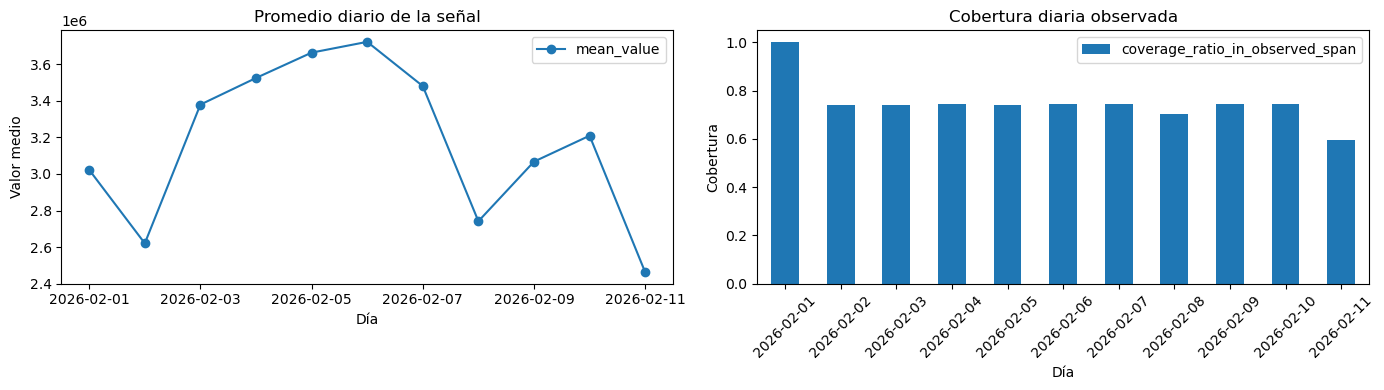

In [7]:
daily_product_view = daily_df.copy()
daily_product_view["coverage_flag"] = daily_product_view[
    "coverage_ratio_in_observed_span"
].map(coverage_flag)
daily_product_view["signal_direction_vs_open"] = np.where(
    daily_product_view["delta_close_open"] >= 0,
    "cierra arriba",
    "cierra abajo",
)
daily_product_view["daily_readiness"] = daily_product_view["coverage_flag"].map(readiness_label)
daily_product_view["range_span"] = daily_product_view["max_value"] - daily_product_view["min_value"]

display(
    daily_product_view[
        [
            "date",
            "mean_value",
            "median_value",
            "coverage_ratio_in_observed_span",
            "coverage_flag",
            "signal_direction_vs_open",
            "daily_readiness",
            "range_span",
        ]
    ].round(3)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
daily_product_view.plot(
    x="date",
    y="mean_value",
    kind="line",
    marker="o",
    ax=axes[0],
    title="Promedio diario de la señal",
)
daily_product_view.plot(
    x="date",
    y="coverage_ratio_in_observed_span",
    kind="bar",
    ax=axes[1],
    title="Cobertura diaria observada",
)
axes[0].set_xlabel("Día")
axes[0].set_ylabel("Valor medio")
axes[1].set_xlabel("Día")
axes[1].set_ylabel("Cobertura")
plt.xticks(rotation=45)
plt.tight_layout()


Aquí ya empiezo a ver qué puede llegar a la UI. Me interesa especialmente que la métrica diaria viaje acompañada de cobertura y de una lectura simple sobre cómo cerró el día. Eso hace que el dashboard sea más interpretable y que el bot tenga mejores respuestas base.


## 6. Quiero construir una vista horaria reusable

La capa horaria es probablemente la más útil para producto: sirve para baseline, para comparaciones intradía y para explicar desviaciones. En esta celda no solo la muestro; también la etiqueto en términos de cobertura y preparación para uso en producto.


,hour_bucket,mean_value,n_points,hourly_coverage_ratio,coverage_flag,baseline_mean,zscore_vs_hour_baseline,deviation_direction,product_readiness
0,2026-02-01 06:00:00-05:00,14308.182,292,0.811,media,NaN,NaN,bajo baseline,usar con cautela
1,2026-02-01 07:00:00-05:00,33525.194,360,1.000,alta,37830.637,-1.756,bajo baseline,lista para producto
2,2026-02-01 08:00:00-05:00,327084.922,360,1.000,alta,371885.142,-1.230,bajo baseline,lista para producto
3,2026-02-01 09:00:00-05:00,1036629.617,360,1.000,alta,1234259.912,-1.389,bajo baseline,lista para producto
4,2026-02-01 10:00:00-05:00,1836326.058,360,1.000,alta,2154595.881,-1.249,bajo baseline,lista para producto
5,2026-02-01 11:00:00-05:00,2490756.769,360,1.000,alta,2883112.941,-1.151,bajo baseline,lista para producto
6,2026-02-01 12:00:00-05:00,3277011.719,360,1.000,alta,3726390.189,-1.127,bajo baseline,lista para producto
7,2026-02-01 13:00:00-05:00,4125768.322,360,1.000,alta,4510962.885,-0.901,bajo baseline,lista para producto
8,2026-02-01 14:00:00-05:00,4868588.061,360,1.000,alta,5158839.693,-0.647,bajo baseline,lista para producto
9,2026-02-01 15:00:00-05:00,5159276.953,360,1.000,alta,5199510.025,-0.053,bajo baseline,lista para producto


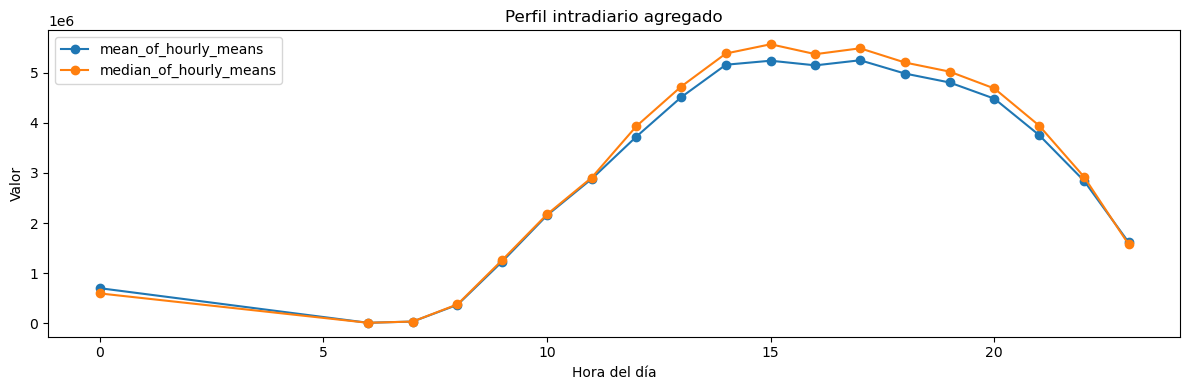

In [8]:
hourly_product_view = hourly_df.copy()
hourly_product_view["hourly_coverage_ratio"] = hourly_product_view["n_points"].map(hourly_coverage_ratio)
hourly_product_view["coverage_flag"] = hourly_product_view["hourly_coverage_ratio"].map(coverage_flag)
hourly_product_view["baseline_available"] = hourly_product_view["baseline_mean"].notna()
hourly_product_view["product_readiness"] = hourly_product_view.apply(
    lambda row: readiness_label(row["coverage_flag"], bool(row["baseline_available"])),
    axis=1,
)
hourly_product_view["deviation_direction"] = np.where(
    hourly_product_view["delta_vs_hour_median"] >= 0,
    "sobre baseline",
    "bajo baseline",
)

display(
    hourly_product_view[
        [
            "hour_bucket",
            "mean_value",
            "n_points",
            "hourly_coverage_ratio",
            "coverage_flag",
            "baseline_mean",
            "zscore_vs_hour_baseline",
            "deviation_direction",
            "product_readiness",
        ]
    ].head(24).round(3)
)

hour_profile = (
    hourly_product_view.groupby("hour")
    .agg(
        mean_of_hourly_means=("mean_value", "mean"),
        median_of_hourly_means=("mean_value", "median"),
        avg_hourly_coverage=("hourly_coverage_ratio", "mean"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 4))
hour_profile.plot(
    x="hour",
    y=["mean_of_hourly_means", "median_of_hourly_means"],
    marker="o",
    ax=ax,
    title="Perfil intradiario agregado",
)
ax.set_xlabel("Hora del día")
ax.set_ylabel("Valor")
plt.tight_layout()


Esta vista me importa mucho porque es casi una especificación funcional del producto. Si una hora tiene baseline y cobertura razonables, puedo construir comparaciones robustas. Si no, el bot debería contestar con más cautela o directamente decir que la evidencia es insuficiente.


## 7. Quiero revisar anomalías con un criterio más prudente

No quiero quedarme con una tabla de z-scores y declararla insight. En esta celda añado un contexto mínimo de confianza para decidir qué anomalías valen la pena para dashboard o demo y cuáles conviene dejar solo como hallazgos exploratorios.


In [9]:
reviewed_anomalies = anomaly_df.copy()
reviewed_anomalies["hourly_coverage_ratio"] = reviewed_anomalies["n_points"].map(hourly_coverage_ratio)
reviewed_anomalies["coverage_flag"] = reviewed_anomalies["hourly_coverage_ratio"].map(coverage_flag)
reviewed_anomalies["surface_in_demo"] = np.where(
    (reviewed_anomalies["hourly_coverage_ratio"] >= 0.95)
    & (reviewed_anomalies["zscore_vs_hour_baseline"].abs() >= 1.5),
    "sí",
    "con cautela",
)

reviewed_step_changes = step_change_df.copy()
reviewed_step_changes["review_priority"] = np.select(
    [
        (~reviewed_step_changes["is_gap_or_reset"]) & (reviewed_step_changes["delta_10s"].abs() >= 100000),
        ~reviewed_step_changes["is_gap_or_reset"],
    ],
    ["alta", "media"],
    default="baja",
)

display(reviewed_anomalies.round(3))
display(reviewed_step_changes.round(3))


,hour_bucket,date,hour,mean_value,baseline_mean,baseline_median,baseline_std,zscore_vs_hour_baseline,delta_vs_hour_median,n_points,anomaly_direction,hourly_coverage_ratio,coverage_flag,surface_in_demo
0,2026-02-10 16:00:00-05:00,2026-02-10,16,3337992.989,5146310.459,5369630.828,904518.168,-1.999,-2031637.839,360,low,1.000,alta,sí
1,2026-02-10 15:00:00-05:00,2026-02-10,15,3686896.392,5199510.025,5363055.850,759737.505,-1.991,-1676159.458,360,low,1.000,alta,sí
2,2026-02-02 14:00:00-05:00,2026-02-02,14,4273888.183,5158839.693,5382707.861,448866.217,-1.972,-1108819.678,360,low,1.000,alta,sí
3,2026-02-02 19:00:00-05:00,2026-02-02,19,3788506.917,4915295.709,5093007.081,573341.886,-1.965,-1304500.164,360,low,1.000,alta,sí
4,2026-02-08 19:00:00-05:00,2026-02-08,19,3809549.000,4915295.709,5093007.081,573341.886,-1.929,-1283458.081,3,low,0.008,baja,con cautela
5,2026-02-02 13:00:00-05:00,2026-02-02,13,3700439.575,4510962.885,4723546.147,427493.137,-1.896,-1023106.572,360,low,1.000,alta,sí
6,2026-02-02 21:00:00-05:00,2026-02-02,21,2972146.797,3757024.357,3945847.694,415250.436,-1.890,-973700.897,360,low,1.000,alta,sí
7,2026-02-02 17:00:00-05:00,2026-02-02,17,4026046.533,5247763.445,5486271.261,663536.402,-1.841,-1460224.728,360,low,1.000,alta,sí
8,2026-02-02 20:00:00-05:00,2026-02-02,20,3473206.486,4482142.386,4685403.554,558141.899,-1.808,-1212197.068,360,low,1.000,alta,sí
9,2026-02-02 12:00:00-05:00,2026-02-02,12,3022421.664,3726390.189,3934228.589,398630.156,-1.766,-911806.925,360,low,1.000,alta,sí


,timestamp,value,delta_10s,pct_change_10s,is_gap_or_reset,timestamp_occurrences,has_conflicting_values,review_priority
0,2026-02-05 06:11:20-05:00,0,-1134935.0,-100.000,True,1,False,baja
1,2026-02-02 23:08:50-05:00,1479469,-399030.0,-21.242,True,1,False,baja
2,2026-02-09 20:40:50-05:00,3712403,195324.0,5.554,False,1,False,alta
3,2026-02-06 08:04:00-05:00,237035,187523.0,378.743,True,1,False,baja
4,2026-02-09 20:45:50-05:00,4366257,-186481.0,-4.096,False,1,False,alta
5,2026-02-09 20:46:00-05:00,4197397,-168860.0,-3.867,False,1,False,alta
6,2026-02-09 20:41:00-05:00,3876953,164550.0,4.432,False,1,False,alta
7,2026-02-09 20:41:10-05:00,4025112,148159.0,3.822,False,1,False,alta
8,2026-02-10 16:39:00-05:00,3919500,145161.0,3.846,False,1,False,alta
9,2026-02-09 20:46:10-05:00,4052578,-144819.0,-3.450,False,1,False,alta


Esta celda me obliga a ser conservador. Una anomalía no es solo un número raro; es una desviación que además quiero poder defender frente a preguntas sobre cobertura, baseline y evidencia. Ese filtro es el que le da seriedad a la demo.


## 8. Quiero dejar un catálogo explícito de métricas reutilizables

Antes de cerrar, quiero convertir todo esto en un pequeño catálogo de lo que ya está listo para backend, dashboard y bot. Esto me ayuda a no perderme entre archivos y tablas.


In [10]:
metric_catalog = pd.DataFrame(
    [
        {
            "metric_family": "overview_period",
            "source": "availability_daily.csv",
            "granularity": "día / rango",
            "why_useful": "Resume nivel de señal y cobertura del período consultado.",
            "dashboard_ready": "sí",
            "bot_ready": "sí",
        },
        {
            "metric_family": "intraday_baseline",
            "source": "availability_hourly.csv",
            "granularity": "hora",
            "why_useful": "Permite comparar una hora contra su comportamiento típico.",
            "dashboard_ready": "sí",
            "bot_ready": "sí",
        },
        {
            "metric_family": "anomaly_candidates",
            "source": "availability_hourly_anomalies.csv",
            "granularity": "hora",
            "why_useful": "Ayuda a señalar desviaciones defendibles con soporte estadístico básico.",
            "dashboard_ready": "con cautela",
            "bot_ready": "sí, con guardrails",
        },
        {
            "metric_family": "step_changes",
            "source": "availability_step_changes.csv",
            "granularity": "10 segundos",
            "why_useful": "Sirve para inspección técnica y explicación de rupturas bruscas.",
            "dashboard_ready": "no prioritario",
            "bot_ready": "solo como apoyo técnico",
        },
        {
            "metric_family": "data_quality",
            "source": "availability_quality_report.json + availability_window_metadata.csv",
            "granularity": "dataset / día / ventana",
            "why_useful": "Aporta trazabilidad, cobertura y confianza.",
            "dashboard_ready": "sí",
            "bot_ready": "sí",
        },
    ]
)

display(metric_catalog)


,metric_family,source,granularity,why_useful,dashboard_ready,bot_ready
0,overview_period,availability_daily.csv,día / rango,Resume nivel de señal y cobertura del período ...,sí,sí
1,intraday_baseline,availability_hourly.csv,hora,Permite comparar una hora contra su comportami...,sí,sí
2,anomaly_candidates,availability_hourly_anomalies.csv,hora,Ayuda a señalar desviaciones defendibles con s...,con cautela,"sí, con guardrails"
3,step_changes,availability_step_changes.csv,10 segundos,Sirve para inspección técnica y explicación de...,no prioritario,solo como apoyo técnico
4,data_quality,availability_quality_report.json + availabilit...,dataset / día / ventana,"Aporta trazabilidad, cobertura y confianza.",sí,sí


## 9. Qué me llevo al notebook final

Termino esta fase con una idea mucho más nítida:

- ya tengo una capa procesada con contrato técnico claro,
- sé qué tablas sirven para producto y cuáles son más de soporte,
- puedo hablar de cobertura y readiness en lugar de mostrar números desnudos,
- estoy listo para decidir qué métricas merecen entrar al dashboard y qué preguntas debería contestar el bot.

El siguiente notebook, entonces, debe enfocarse en convertir esta capa procesada en decisiones concretas de producto y demo.
